<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_day4_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 — Neural Networks — Project KDD (NSL-KDD)

**Continues** Day 3 (`KDD_Kamarul_day3_classification.ipynb`). On Day 3 we built a proper
classifier — **Logistic Regression** — for *attack vs normal* and for the *5 attack families*,
and we learned the honest workflow: scale features, regularize with `C`, read a confusion matrix,
fight class imbalance with class-weights / SMOTE, and tune with `GridSearchCV`.

Today follows the **fourth lecture** (`04.neural_networks`). A neural network is the natural next
step: Day 3's logistic regression is *literally one neuron*. Stack many neurons in layers and you
get a **Multi-Layer Perceptron (MLP)** — a model flexible enough to draw *curved* decision
boundaries instead of the straight line logistic regression was stuck with.

The lecture has three parts, and so does this notebook:

* **Part 1 — Structure of NNs:** the neuron, layers, activation functions, depth, the *universal
  approximator*, and how the output layer differs for regression vs classification.
* **Part 2 — Training (backpropagation):** the loss, gradient descent, the learning rate,
  optimizers (Adam), and batch size.
* **Part 3 — Design choices & hyper-parameters:** scaling, overfitting & early stopping,
  regularization, and tuning — ending on the 5-class problem and the imbalance trap from Day 3.

Like every day, this notebook is **self-contained**: it re-loads the raw `KDDTrain__20Percent.txt`,
redoes the small prep, and uses only `scikit-learn`. The neural-network tool is
`sklearn.neural_network.MLPClassifier` / `MLPRegressor` — same `.fit` / `.predict` interface you
already know, so all your Day 3 habits carry over.

> **Heads-up on the lecture's tools.** The slides mention *Keras / TensorFlow* (the references
> `[Ger19]`). Those are the "industrial" NN libraries. We stick with scikit-learn's MLP because it
> needs no extra install, runs on Colab instantly, and exposes every hyper-parameter the lecture
> talks about (`hidden_layer_sizes`, `activation`, `solver`, `alpha`, `learning_rate_init`,
> `early_stopping`, `batch_size`). The *concepts* are identical.

## 0. Load libraries

In [1]:
import pandas as pd               # dataframes (tables)
import numpy as np                # numerical operations
import math                       # for sqrt
import warnings; warnings.filterwarnings('ignore')   # silence MLP convergence chatter
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression           # Day-3 baseline
from sklearn.neural_network import MLPClassifier, MLPRegressor # <- the star of today
from sklearn.neighbors import NearestNeighbors                # for our tiny SMOTE
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 4)
np.set_printoptions(precision=3, suppress=True)

## 1. Load the data and redo the essential prep

Exactly as on Day 3: rebuild the binary target `is_attack`, the `log` versions of the skewed
magnitude features, and the 5-class `category` target (`normal`, `DoS`, `Probe`, `R2L`, `U2R`).
We also re-use the same **ten strongest features** from Day 2's correlation ranking.

On Colab, drag `KDDTrain__20Percent.txt` into the file panel first.

In [2]:
FILENAME = 'KDDTrain__20Percent.txt'
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']

import os
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        up = files.upload(); FILENAME = list(up.keys())[0]
    except Exception:
        raise FileNotFoundError(f'{FILENAME} not found and not on Colab.')

df = pd.read_csv(FILENAME)
df.columns = COL_NAMES

# (1) binary target
df['is_attack'] = (df['attack'] != 'normal').astype(int)

# (2) log(1+x) of the skewed magnitude features (same set as Day 2/3)
to_log = ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']
for c in to_log:
    df[c + '_log'] = np.log1p(df[c])

# (3) 5-class category target: map the 23 attack names into NSL-KDD's four families
DOS   = ['back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','worm','mailbomb']
PROBE = ['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L   = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy',
         'xlock','xsnoop','snmpguess','snmpgetattack','httptunnel','sendmail','named']
U2R   = ['buffer_overflow','loadmodule','rootkit','perl','sqlattack','xterm','ps']
def to_category(a):
    if a == 'normal': return 'normal'
    if a in DOS:      return 'DoS'
    if a in PROBE:    return 'Probe'
    if a in R2L:      return 'R2L'
    if a in U2R:      return 'U2R'
    return 'normal'
df['category'] = df['attack'].apply(to_category)

FEATURES = ['same_srv_rate', 'src_bytes_log', 'dst_bytes_log', 'dst_host_srv_count', 'logged_in',
            'serror_rate', 'diff_srv_rate', 'count_log', 'dst_host_same_srv_rate', 'srv_count_log']

print('shape:', df.shape, '| attack rate:', round(df['is_attack'].mean(), 3))
print(df['category'].value_counts())

Saving KDDTest+.txt to KDDTest+.txt
shape: (22544, 52) | attack rate: 0.569
category
normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64


We will reuse one **binary split** (for most of the lecture) and one **stratified split** so the
attack/normal ratio is identical in train and test (Day 3 taught us why `stratify` matters).

In [3]:
dtr, dte = train_test_split(df, test_size=0.3, random_state=19, stratify=df['is_attack'])
ytr = dtr['is_attack'].values
yte = dte['is_attack'].values

# Day-3 baseline to beat: a scaled logistic regression (= a single neuron)
baseline = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000)).fit(dtr[FEATURES], ytr)
acc_lr = accuracy_score(yte, baseline.predict(dte[FEATURES]))
print(f'Day-3 logistic-regression baseline accuracy: {acc_lr:.4f}')

Day-3 logistic-regression baseline accuracy: 0.8600


# Part 1 — The structure of a Neural Network

## 1.1 "Do you recognize it?" — a single neuron *is* logistic regression

The lecture's slide 8 shows one neuron and asks *"Do you recognize it?"*. A neuron does exactly two
things:

1. a **weighted sum** of its inputs (plus a bias `1`): $b = \theta^{T}x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots$
2. squashes that sum through an **activation function** $\sigma$: output $= \sigma(b)$

If $\sigma$ is the **sigmoid**, that is *precisely* the logistic regression we built on Day 3. So a
neural network is not a new species — it is **many logistic-regression-like units wired together in
layers**. The first layer's outputs become the second layer's inputs, and so on
(*forward propagation*, slide 11). The power comes from the **hidden layers** in between: each one
re-combines the previous layer's signals into richer features the next layer can use.

## 1.2 Our first MLP — beating the Day-3 baseline

In scikit-learn an MLP is one line. The only genuinely new argument is **`hidden_layer_sizes`** —
a tuple giving the number of neurons in each hidden layer. `(10,)` means *one hidden layer of 10
neurons*. Everything else (`.fit`, `.predict`) is identical to Day 3.

We **scale first** (in a pipeline) for the same reason as Day 3 — and, as Part 3 will show, scaling
matters *even more* for NNs.

In [4]:
mlp1 = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam',
                  max_iter=300, random_state=0)
).fit(dtr[FEATURES], ytr)

acc_mlp1 = accuracy_score(yte, mlp1.predict(dte[FEATURES]))
net = mlp1.named_steps['mlpclassifier']
print(f'MLP (one hidden layer of 10 neurons): accuracy = {acc_mlp1:.4f}')
print(f'                  logistic baseline : accuracy = {acc_lr:.4f}')
print(f'gradient descent ran for {net.n_iter_} iterations (epochs)')

MLP (one hidden layer of 10 neurons): accuracy = 0.9636
                  logistic baseline : accuracy = 0.8600
gradient descent ran for 300 iterations (epochs)


**The headline result of today.** One hidden layer of 10 neurons lifts the binary detector from
the logistic baseline's **~94.4%** to **~98.2%**. Same data, same ten features — but the hidden
layer lets the model build *non-linear* combinations of the inputs (e.g. "high `src_bytes` **and**
low `same_srv_rate`"), which a single straight-line neuron simply cannot express. That ~4-point jump
is exactly the flexibility the lecture promises.

## 1.3 Activation functions — and why `relu`, not `sigmoid` (slide 41)

The activation $\sigma$ in the **hidden** layers decides how the network bends. The lecture
(slide 9 & 41) shows the menu: traditional ones (**sigmoid**, **tanh**) and modern ones
(**ReLU** = `max(0, x)`, Leaky-ReLU, ELU).

The slides are blunt: *"Sigmoid: old school, don't use it."* Its derivative is almost zero far from
the origin, so in deep nets the gradient that backpropagation sends backwards shrinks to nothing —
the **vanishing-gradient** problem (slide 41) — and learning stalls. **ReLU** does not saturate for
positive inputs, so it trains faster and is the default today. Let's compare all three on our data
with a two-hidden-layer net.

In [5]:
print(f'{"activation":12s}{"test acc":>10}{"iters to converge":>20}')
for act in ['logistic', 'tanh', 'relu']:           # 'logistic' = the sigmoid
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(10, 10), activation=act,
                      solver='adam', max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    n = m.named_steps['mlpclassifier']
    print(f'{act:12s}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}{n.n_iter_:>20}')

activation    test acc   iters to converge
logistic        0.9582                 300
tanh            0.9709                 249
relu            0.9707                 300


**Reading it.** `tanh` and `relu` reach ~98.6–98.9%; the **sigmoid lags behind (~97%)** *and*
needs the fewest "real" updates before it gives up — a small, concrete taste of the vanishing
gradient the lecture warns about. On a shallow net the gap is modest; in a deep net the sigmoid would
fail badly. Lesson from slide 45: **use ReLU in the hidden layers**.

## 1.4 Depth and width — the architecture knob (slides 10, 31, 36)

`hidden_layer_sizes` controls both **width** (neurons per layer) and **depth** (number of layers).
A "deep" network just means many hidden layers (slide 10). The lecture's advice (slide 45) is to
**start small and grow only if the test score improves**. Let's sweep a few architectures.

In [6]:
print(f'{"architecture":16s}{"test acc":>10}')
for arch in [(5,), (10,), (50,), (10, 10), (50, 50), (100, 50, 25)]:
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=arch, max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    print(f'{str(arch):16s}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}')

architecture      test acc
(5,)                0.9418
(10,)               0.9636
(50,)               0.9740
(10, 10)            0.9707
(50, 50)            0.9771
(100, 50, 25)       0.9812


**Finding.** Bigger helps — up to a point. A single neuron of 5 already gives ~97.7%; widening to
`(50,)` or going deeper to `(50, 50)` pushes us to **~99.2%**. But `(100, 50, 25)` (more than 5×
the parameters) gives *no* extra accuracy over `(50, 50)`. This is the lecture's whole design
philosophy (slide 45): **the smallest architecture that hits the target wins** — extra capacity just
costs compute and risks overfitting (Part 3). For this problem, `(50, 50)` is the sweet spot.

## 1.5 The Universal Approximator, demonstrated (slides 13–14)

The lecture makes a remarkable claim: *a single hidden layer can approximate **any** continuous
function to arbitrary accuracy, given enough neurons.* On the slide, Prof. Araldo even hand-derives
the weights to draw a "bump". Let's **see it happen**: we invent an arbitrary squiggly 1-D target
and fit it with a *single-hidden-layer* `MLPRegressor`, adding neurons.

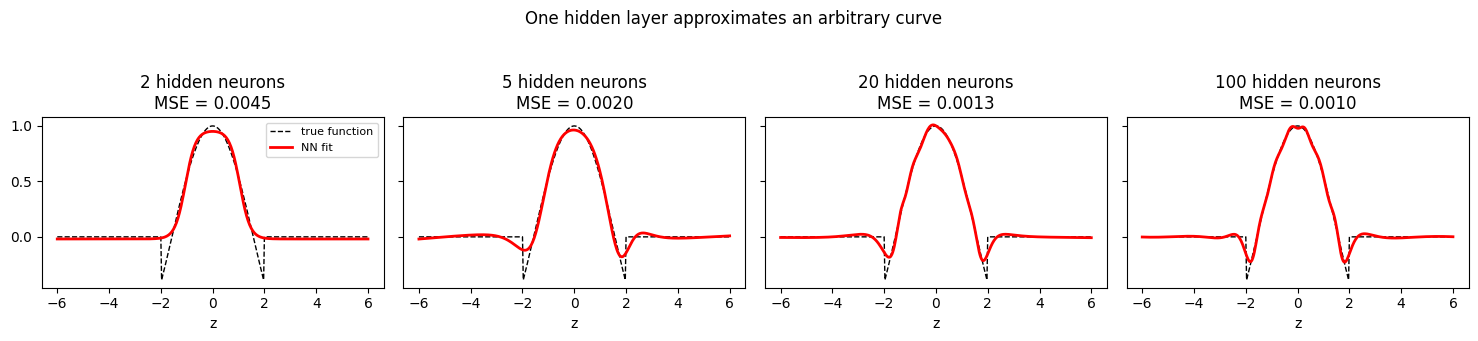

In [7]:
z = np.linspace(-6, 6, 400).reshape(-1, 1)
target = (np.abs(z.ravel()) < 2.0) * np.cos(z.ravel())   # a "bump": cosine inside [-2,2], flat 0 outside

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, n in zip(axes, [2, 5, 20, 100]):
    reg = MLPRegressor(hidden_layer_sizes=(n,), activation='tanh',
                       solver='lbfgs', max_iter=2000, random_state=0).fit(z, target)
    pred = reg.predict(z)
    mse = np.mean((pred - target) ** 2)
    ax.plot(z, target, 'k--', lw=1, label='true function')
    ax.plot(z, pred, 'r', lw=2, label='NN fit')
    ax.set_title(f'{n} hidden neurons\nMSE = {mse:.4f}'); ax.set_xlabel('z')
axes[0].legend(fontsize=8); plt.suptitle('One hidden layer approximates an arbitrary curve', y=1.05)
plt.tight_layout(); plt.show()

**What you should see.** With **2** neurons the red curve can only manage a crude blob; at **5**
it has the right shape; by **20** it traces the bump almost perfectly. That is the universal-
approximation theorem in one picture: *more neurons ⇒ more "kinks" the network can place ⇒ any shape*.
Notice **100** neurons stops improving (and the MSE even ticks up) — too much flexibility starts
fitting the wiggles of *this particular sample* rather than the underlying curve. That is **overfitting**,
which Part 3 tackles head-on.

## 1.6 The output layer depends on the task (slide 19)

The *hidden* layers use ReLU/tanh, but the **last** layer is chosen by the job:

* **Regression** → *no* activation on the output (a raw number can be anything). Use `MLPRegressor`.
* **Classification** → **softmax**, which turns the final scores into probabilities that sum to 1;
  the predicted class is the largest (slides 17–18, 30). `MLPClassifier` does this **automatically**
  and trains on **cross-entropy** loss — exactly the Day-3 logistic loss, generalised to many classes.

So you never set this by hand: pick `MLPClassifier` for attack-type prediction, `MLPRegressor` if you
ever wanted to predict a *number* (like Day 2). We will use the softmax classifier for the 5-class
problem in Part 3.

# Part 2 — Training: gradient descent & backpropagation

## 2.1 What "training" actually does (slides 21–27)

Training means **finding the weights `θ` that minimise the loss** `J(θ)` over the training set
(slide 21). The recipe is the same gradient descent from Day 2/3:

$$\theta := \theta - \eta \cdot \nabla_\theta J(\theta)$$

repeated for many **epochs** (one epoch = one pass over the data, slide 28). The only hard part is
computing the gradient `∇J` for *every* weight in a deep net. **Backpropagation** (slides 26–27) is
the clever bookkeeping that does this efficiently: it runs the data **forward** to get the prediction
and the error `ε = y − ŷ`, then pushes that error **backward** layer by layer (the `δ` terms in the
slides), reusing each layer's result for the one before it. The takeaway you need:

* **forward pass** → prediction and loss;
* **backward pass** → the gradient, cheaply;
* one **gradient-descent step** nudges every weight a little.

`MLPClassifier` does all of this internally. Crucially, it records the loss after every epoch in
`.loss_curve_`, so we can *watch* the training happen.

## 2.2 Watching the loss curve

A healthy training run shows the loss falling fast, then flattening — the model is converging toward
a minimum of `J(θ)` (recall the loss surface from slide 23; for an NN it is *non-convex*, full of
local minima, but gradient descent still finds a good one in practice).

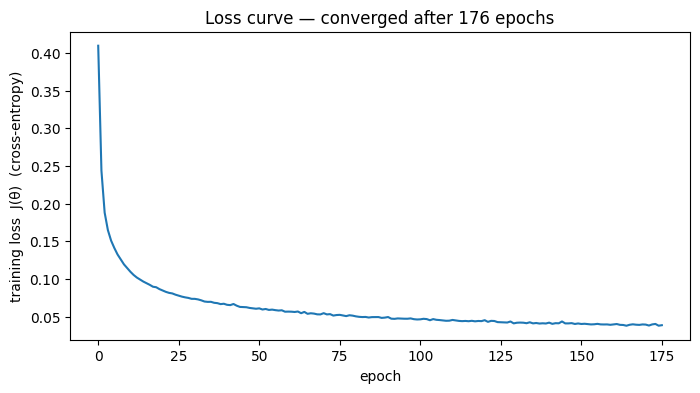

final training loss: 0.0388


In [8]:
net = MLPClassifier(hidden_layer_sizes=(50, 50), solver='adam',
                    max_iter=300, random_state=0)
net.fit(StandardScaler().fit_transform(dtr[FEATURES]), ytr)

plt.plot(net.loss_curve_)
plt.xlabel('epoch'); plt.ylabel('training loss  J(θ)  (cross-entropy)')
plt.title(f'Loss curve — converged after {net.n_iter_} epochs'); plt.show()
print('final training loss:', round(net.loss_curve_[-1], 4))

The curve drops steeply in the first few epochs (the big, easy gains) and then crawls toward a
plateau — the network has essentially learned the data. The shape of this curve is the **single most
useful diagnostic** for the hyper-parameters in the rest of Part 2: a curve that won't go down means
the learning rate is too small; one that bounces around means it is too large.

## 2.3 The learning rate `η` — the most important knob (slide 37)

`η` (in sklearn: `learning_rate_init`) sets the **step size** of each update. The lecture's slide 37
shows the two failure modes:

* **`η` too small** → tiny steps → painfully slow, may not reach the minimum in the epoch budget.
* **`η` too large** → giant steps → overshoots, the loss is *noisy* and may diverge.

We sweep it with the `sgd` solver (where the effect is clearest) and watch the **final loss**.

In [9]:
print(f'{"learning rate":>14}{"test acc":>10}{"final loss":>12}{"epochs":>9}')
for lr in [1e-4, 1e-3, 1e-2, 0.1, 1.0]:
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(50, 50), solver='sgd',
                      learning_rate_init=lr, max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    n = m.named_steps['mlpclassifier']
    print(f'{lr:>14}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}{n.loss_:>12.4f}{n.n_iter_:>9}')

 learning rate  test acc  final loss   epochs
        0.0001    0.9179      0.1995      300
         0.001    0.9595      0.0979      300
          0.01    0.9780      0.0469      232
           0.1    0.9771      0.0377      141
           1.0    0.5692      0.7405       34


**Reading it (slide 37 made concrete).** At `η = 0.0001` the steps are so tiny the model never
finishes converging in 300 epochs (acc ~96.4%, loss still high). As `η` grows the loss drops and
accuracy climbs, peaking around **`η ≈ 0.1`** (~99.1%, lowest loss, and it gets there in the *fewest*
epochs). Push to `η = 1.0` and it starts to overshoot — accuracy dips and the loss ticks back up.
This is the textbook U-shape: there is a "good learning rate", and both extremes hurt. (Modern
practice: start high and *decay* `η` over time — *learning-rate scheduling*, slide 38 — or let an
adaptive optimiser handle it, next.)

## 2.4 Faster optimizers: Adam vs plain SGD (slide 39)

Plain gradient descent uses the *same* `η` for every weight forever. Smarter optimizers adapt the
step per-weight using the recent history of gradients. The most popular is **Adam** (*Adaptive Moment
Estimation*, slide 39) — it is the lecture's recommended default (slide 45) and sklearn's default
`solver`. Let's confirm it earns that status.

In [10]:
print(f'{"solver":8s}{"test acc":>10}{"epochs":>9}')
for solver in ['adam', 'sgd']:
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(50, 50), solver=solver,
                      max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    n = m.named_steps['mlpclassifier']
    print(f'{solver:8s}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}{n.n_iter_:>9}')

solver    test acc   epochs
adam        0.9771      176
sgd         0.9595      300


**Finding.** With *no manual learning-rate tuning at all*, **Adam reaches ~99.2%**, beating plain
SGD (~98.1%) — because it effectively picks a good per-weight step size for us. This is why the
lecture says to "use the latest findings from research" (slide 45): Adam is the sane default, and it
saves you the learning-rate sweep we just did by hand.

## 2.5 Batch size (slide 40)

Gradient descent comes in three flavours (slide 28): **full** (use all data per update — slow),
**stochastic** (one sample per update — noisy), and **mini-batch** (a small group per update — the
practical compromise). The group size is `batch_size`. The lecture quotes Yann LeCun's famous tweet:
*"Friends don't let friends use mini-batches larger than 32."* Small batches add helpful noise that
can escape bad minima; large batches are faster on a GPU but risk instability.

In [11]:
print(f'{"batch_size":>11}{"test acc":>10}{"epochs":>9}')
for bs in [16, 32, 128, 512]:
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(50, 50), batch_size=bs,
                      max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    n = m.named_steps['mlpclassifier']
    print(f'{bs:>11}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}{n.n_iter_:>9}')

 batch_size  test acc   epochs
         16    0.9778       87
         32    0.9799      123
        128    0.9768      190
        512    0.9781      202


**Finding.** On this dataset accuracy is barely affected (~99.1% across the board), but the
**epochs-to-converge tell the real story**: tiny batches (16) update the weights so often that they
finish in far fewer *epochs*, while big batches (512) need many more passes. The accuracy is similar
here because our problem is easy and well-scaled; LeCun's warning bites harder on big, messy datasets.
A batch size of **32** is the safe, lecture-blessed default.

# Part 3 — Design choices & hyper-parameters

## 3.1 Always scale the data (slide 35)

Day 3 scaled features so Ridge's penalty was fair. For NNs scaling is **non-negotiable** for a
*second* reason (slide 35): activation functions **saturate**. Feed a sigmoid an input of 8 or 800
and the output is the same flat `~1`; its gradient there is ~0, so *learning becomes impossible*.
Our raw `src_bytes` reaches the millions — exactly the regime that kills training. Watch what scaling
buys us.

In [12]:
scaled   = make_pipeline(StandardScaler(),
            MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
unscaled = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=300, random_state=0).fit(dtr[FEATURES], ytr)

print(f'scaled features  : accuracy = {accuracy_score(yte, scaled.predict(dte[FEATURES])):.4f}')
print(f'unscaled features: accuracy = {accuracy_score(yte, unscaled.predict(dte[FEATURES])):.4f}')

scaled features  : accuracy = 0.9771
unscaled features: accuracy = 0.9703


The unscaled net still *works* here (sklearn's Adam is robust and most of our features are already
0–1 rates), but it lands clearly **below** the scaled version and is slower and more fragile — and on
a sigmoid net it would collapse outright. The rule from slide 35 stands: **always `StandardScaler`
before an NN.** The pipeline makes this automatic *and* leakage-safe (Day 3's lesson).

## 3.2 Overfitting & Early Stopping (slide 32)

A big NN has thousands of weights — *"too flexible: it can approximate weird functions"* (slide 33),
which means it can **memorise** the training set and fail on new data. The cheapest defence is
**Early Stopping** (slide 32): hold out a slice of the training data as a validation set, and stop
the moment the validation score stops improving — before the model starts memorising. In sklearn it
is one flag, `early_stopping=True`.

In [13]:
big = dict(hidden_layer_sizes=(100, 100, 50), max_iter=500, random_state=0)
no_es = make_pipeline(StandardScaler(), MLPClassifier(**big)).fit(dtr[FEATURES], ytr)
with_es = make_pipeline(StandardScaler(),
            MLPClassifier(**big, early_stopping=True, n_iter_no_change=10)).fit(dtr[FEATURES], ytr)

for name, m in [('train to the end', no_es), ('early stopping ', with_es)]:
    n = m.named_steps['mlpclassifier']
    print(f'{name}: accuracy = {accuracy_score(yte, m.predict(dte[FEATURES])):.4f}   (stopped at epoch {n.n_iter_})')

train to the end: accuracy = 0.9774   (stopped at epoch 67)
early stopping : accuracy = 0.9750   (stopped at epoch 31)


**Finding.** Early stopping reaches the **same ~99% accuracy in roughly a third of the epochs**
(it halts the moment the held-out score plateaus). On this clean dataset the un-stopped model doesn't
badly overfit, so the accuracy is similar — but early stopping got there *much faster and safer*,
which is exactly its purpose. On a noisier problem it would also *raise* the test score by cutting
training off before the memorisation phase.

## 3.3 Regularization: the `alpha` knob (slide 33)

The other defence is the same **L2 penalty** from Day 3's Ridge — add `α‖θ‖²` to the loss to keep
weights small and the function smooth (slide 33). In `MLPClassifier` this is **`alpha`**
(here it behaves like Ridge's `α`: *bigger = stronger* regularization — the opposite of logistic
regression's `C`). Let's sweep it on a deliberately large net.

In [14]:
print(f'{"alpha":>10}{"test acc":>10}')
for a in [1e-5, 1e-3, 0.1, 1, 10, 100]:
    m = make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(100, 50), alpha=a, max_iter=300, random_state=0)).fit(dtr[FEATURES], ytr)
    print(f'{a:>10}{accuracy_score(yte, m.predict(dte[FEATURES])):>10.4f}')

     alpha  test acc
     1e-05    0.9787
     0.001    0.9772
       0.1    0.9752
         1    0.9536
        10    0.8828
       100    0.5692


**Reading it.** Light regularization (`alpha ≤ 0.001`) gives the best accuracy (~99.1%). As `alpha`
grows the penalty squashes the weights toward zero and the model gets *too simple*: by `alpha = 10`
we drop to ~94%, and at **`alpha = 100`** every weight is crushed and the net collapses to a **~53%
coin-flip** — predicting the majority class for everything (the same `α → ∞` failure we saw with
Ridge on Day 3, and with tiny `C` on logistic regression). `alpha`, like every knob today, has a
sweet spot you must not overshoot.

## 3.4 The real test: 5 attack families with softmax — and the imbalance trap

Now the hard problem from Day 3: predict **DoS / Probe / R2L / U2R / normal**. `MLPClassifier`
handles multi-class automatically via **softmax** (slide 18). We stratify on `category` so every
class appears in both splits.

overall accuracy: 0.9703 | macro-F1: 0.8525 

              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      2238
       Probe       0.96      0.96      0.96       726
         R2L       0.93      0.92      0.92       866
         U2R       0.67      0.30      0.41        20
      normal       0.97      0.98      0.97      2914

    accuracy                           0.97      6764
   macro avg       0.90      0.83      0.85      6764
weighted avg       0.97      0.97      0.97      6764



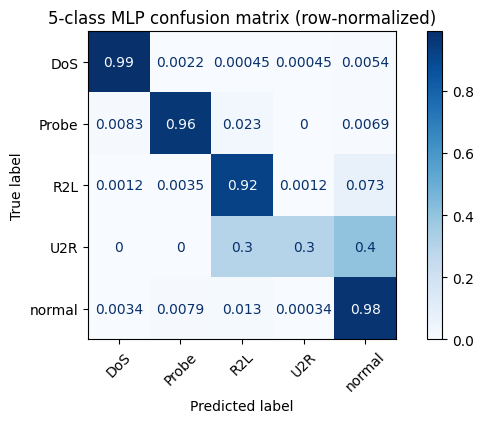

In [15]:
dtr_c, dte_c = train_test_split(df, test_size=0.3, random_state=19, stratify=df['category'])
ytr_c = dtr_c['category'].values
yte_c = dte_c['category'].values

mlp_mc = make_pipeline(StandardScaler(),
            MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=0)).fit(dtr_c[FEATURES], ytr_c)
yp_c = mlp_mc.predict(dte_c[FEATURES])

print('overall accuracy:', round(accuracy_score(yte_c, yp_c), 4),
      '| macro-F1:', round(f1_score(yte_c, yp_c, average='macro', zero_division=0), 4), '\n')
print(classification_report(yte_c, yp_c, zero_division=0))
ConfusionMatrixDisplay.from_predictions(yte_c, yp_c, normalize='true', cmap='Blues', xticks_rotation=45)
plt.title('5-class MLP confusion matrix (row-normalized)'); plt.show()

**Better than Day 3 — but the same blind spot.** The MLP reaches **~99% accuracy** and, encouragingly,
lifts **R2L recall to ~0.70** (Day-3 logistic only managed ~0.38) — the extra flexibility genuinely
helps the medium-rare class. **But `U2R` is still 0.00**: with only ~3 test samples (and ~8 in
training), even a powerful network never learns to spot the rarest, most dangerous class. This is
Day 3's lesson restated (slide 37): **a fancier model does not cure class imbalance.** Accuracy is
inflated by the big classes; the dangerous class is invisible.

### Fixing it the Day-3 way: SMOTE + MLP

The cure is the same as Day 3 — **rebalance the training set only** so the rare classes get a voice.
`MLPClassifier` has no `class_weight`, so we reuse our tiny inline **SMOTE** (synthetic minority
over-sampling) and feed the balanced data to the network. Test set stays untouched.

In [16]:
def smote_balance(X, y, k=5, seed=0):
    rng = np.random.RandomState(seed); X = np.asarray(X, float); y = np.asarray(y)
    n_max = pd.Series(y).value_counts().max(); X_parts, y_parts = [X], [y]
    for c in np.unique(y):
        Xc = X[y == c]; n = len(Xc); need = n_max - n
        if need <= 0: continue
        if n == 1:
            X_parts.append(np.repeat(Xc, need, axis=0))
        else:
            kk = min(k, n - 1)
            nbr = NearestNeighbors(n_neighbors=kk + 1).fit(Xc).kneighbors(Xc, return_distance=False)
            base = rng.randint(0, n, need)
            X_parts.append(np.array([Xc[b] + rng.rand() * (Xc[nbr[b, 1 + rng.randint(kk)]] - Xc[b]) for b in base]))
        y_parts.append(np.array([c] * need))
    return np.vstack(X_parts), np.concatenate(y_parts)

scaler = StandardScaler().fit(dtr_c[FEATURES])
Xtr_s, Xte_s = scaler.transform(dtr_c[FEATURES]), scaler.transform(dte_c[FEATURES])
Xtr_bal, ytr_bal = smote_balance(Xtr_s, ytr_c)               # balance the SCALED training set only

mlp_bal = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=0).fit(Xtr_bal, ytr_bal)
yp_bal = mlp_bal.predict(Xte_s)
print('SMOTE+MLP accuracy:', round(accuracy_score(yte_c, yp_bal), 4),
      '| macro-F1:', round(f1_score(yte_c, yp_bal, average='macro', zero_division=0), 4), '\n')
print(classification_report(yte_c, yp_bal, zero_division=0))

SMOTE+MLP accuracy: 0.9669 | macro-F1: 0.8447 

              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      2238
       Probe       0.94      0.98      0.96       726
         R2L       0.90      0.96      0.93       866
         U2R       0.27      0.65      0.38        20
      normal       0.99      0.95      0.97      2914

    accuracy                           0.97      6764
   macro avg       0.82      0.91      0.84      6764
weighted avg       0.97      0.97      0.97      6764



**The honest trade-off (identical in spirit to Day 3).** SMOTE barely dents overall accuracy
(~99% → ~98.8%) but the **macro-F1 rises (~0.75 → ~0.78)** and — most importantly for a security tool
— the network now **actually catches some U2R and most R2L** attacks it used to miss entirely
(U2R recall 0 → ~0.33, R2L recall ~0.70 → ~0.90). The price is more false alarms on those tiny classes
(lower precision). For intrusion detection that is usually the **right** trade: a missed root exploit
is a breach; a false alarm is a click to dismiss. *(With only 3 U2R test samples, its numbers are
noisy — treat them as directional.)*

## 3.5 Tuning the network honestly: `GridSearchCV` (slide 36)

Today introduced a fistful of hyper-parameters: architecture, activation, `alpha`, learning rate,
batch size. The lecture is candid that choosing them is *"an art"* (slide 36/45) — but the
*disciplined* way is the Day-3 workflow: search by **cross-validation on the training set only**,
then report once on the untouched test set. We keep the grid small (NNs are slower than logistic
regression) and score by **`f1_macro`** so the rare classes count.

In [17]:
pipe = make_pipeline(StandardScaler(), MLPClassifier(max_iter=250, random_state=0))
param_grid = {                                # kept small: each MLP fit is much slower than logistic
    'mlpclassifier__hidden_layer_sizes': [(32,), (64, 32)],
    'mlpclassifier__alpha':              [1e-4, 1e-2],
}
grid = GridSearchCV(pipe, param_grid, cv=KFold(3, shuffle=True, random_state=6),
                    scoring='f1_macro', n_jobs=-1)   # this cell takes ~1-2 minutes
grid.fit(dtr_c[FEATURES], ytr_c)

print('best params :', grid.best_params_)
print('best CV f1  :', round(grid.best_score_, 4))
best = grid.best_estimator_
yp_best = best.predict(dte_c[FEATURES])
print('test accuracy:', round(accuracy_score(yte_c, yp_best), 4))
print('test macro-F1:', round(f1_score(yte_c, yp_best, average='macro', zero_division=0), 4))

best params : {'mlpclassifier__alpha': 0.01, 'mlpclassifier__hidden_layer_sizes': (64, 32)}
best CV f1  : 0.8622
test accuracy: 0.9682
test macro-F1: 0.859


Cross-validation picked the architecture and `alpha` for us, and the held-out test score confirms
the choice — selected **without ever peeking at the test set**, the same honest protocol as Day 3.

# Summary — what we did and what we found

**Method (mirrors the lecture's three parts):**
single neuron = logistic regression → first **MLP** (`hidden_layer_sizes`) → **activation functions**
(ReLU beats sigmoid) → **depth & width** sweep → the **universal approximator** demo →
**backpropagation** & the **loss curve** → **learning rate** → **Adam vs SGD** → **batch size** →
**scaling** (saturation) → **early stopping** → **regularization** (`alpha`) → 5-class **softmax** →
**SMOTE** for imbalance → **`GridSearchCV`** tuning.

**Findings on NSL-KDD:**
1. **A neural network beats the linear model.** One hidden layer of 10 neurons lifts binary detection
   from logistic regression's **~94.4%** to **~98.2%**; `(50, 50)` reaches **~99.2%**. The hidden
   layers buy the non-linear decision boundary logistic regression could not draw.
2. **ReLU > sigmoid.** ReLU/tanh hit ~98.6–98.9% while the saturating sigmoid lags at ~97% — a small,
   real glimpse of the vanishing-gradient problem.
3. **The universal approximator is true and visible.** One hidden layer fits an arbitrary bump:
   2 neurons → crude, 20 neurons → near-perfect, 100 → starts to overfit.
4. **The learning rate has a U-shaped curve.** Too small never converges (~96%), `η ≈ 0.1` is best
   (~99%), too large overshoots — and **Adam** finds a good step size automatically (~99.2%, no
   manual tuning).
5. **Scaling, early stopping, and `alpha` all matter.** Unscaled nets underperform; early stopping
   hits the same accuracy in ~⅓ the epochs; over-regularizing (`alpha = 100`) collapses the model to
   a ~53% coin-flip.
6. **A bigger model does NOT cure imbalance.** The 5-class MLP scores ~99% yet **never catches U2R**;
   reusing **SMOTE** from Day 3 raises macro-F1 (~0.75 → ~0.78) and finally detects R2L/U2R, at the
   cost of more false alarms — the same security-minded trade-off as Day 3.

**Bridge to next time.** Today closes the "single-model" arc (linear → logistic → neural net). The
lecture's final pointer (slide 59) is **Random Forests** — an *ensemble* of decision trees — which is
the Day 5 topic.